<h1 align="center">Laboratorio 5</h1>

## Información

**Integrantes:**

| Name              | Institution ID | GitHub User |
| ----------------- | -------------- | ----------- |
| Josué Say         | 22801          | JosueSay    |
| Carlos Valladares | 221164         | vgcarlol    |

- [Repositorio](https://github.com/JosueSay/intro-to-computer-vision/tree/main/labs/lab5)

## Preparación de entorno

In [2]:
# %pip install -r requirements.txt
# jupyter nbconvert lab5.ipynb --to html

## Librerías y Configuración

In [3]:
import cv2, json
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [4]:
RUN_NAME1 = "run_experiment_01"
RUN_NAME2 = "run_experiment_02"
LOG_JSON_PATH1 = f"{RUN_NAME1}.json"
LOG_JSON_PATH2 = f"{RUN_NAME2}.json"
img1_set1 = "images/set1/img1.png"
img2_set1 = "images/set1/img2.png"

img1_set2 = "images/set2/img1.png"
img2_set2 = "images/set2/img2.png"

logs = {}

In [5]:
def addLog(section, key, value):
    global logs
    if section not in logs:
        logs[section] = {}
    logs[section][key] = value

def saveLogsAsJSON(logsDict, filename):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(logsDict, f, indent=4, ensure_ascii=False)
    print(f"Logs guardados en: {filename}")

In [6]:
def loadImages(leftPath, rightPath):
    imgLeft = cv2.imread(leftPath)
    imgRight = cv2.imread(rightPath)

    if imgLeft is None or imgRight is None:
        raise ValueError("No se pudieron cargar las imágenes")

    return imgLeft, imgRight

In [7]:
def convertToGray(imgLeft, imgRight):
    grayLeft = cv2.cvtColor(imgLeft, cv2.COLOR_BGR2GRAY)
    grayRight = cv2.cvtColor(imgRight, cv2.COLOR_BGR2GRAY)
    return grayLeft, grayRight

## Código Previo

In [8]:
def detectWithSift(grayLeft, grayRight, nFeatures=2000):

    # left se queda fija y right se va a transformar para acoplar con left
    sift = cv2.SIFT_create(nfeatures=nFeatures)

    kpLeft, desLeft = sift.detectAndCompute(grayLeft, None)   # Train (destino)
    kpRight, desRight = sift.detectAndCompute(grayRight, None)  # Query (se transforma)

    addLog("features", "kp_left", len(kpLeft))
    addLog("features", "kp_right", len(kpRight))

    return kpLeft, desLeft, kpRight, desRight

In [9]:
def matchWithFlann(desRight, desLeft, ratio=0.7):

    # FLANN KDTree para SIFT
    FLANN_INDEX_KDTREE = 1
    indexParams = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    searchParams = dict(checks=50)

    flann = cv2.FlannBasedMatcher(indexParams, searchParams)

    # derecha = query, izquierda = train
    matches = flann.knnMatch(desRight, desLeft, k=2)

    # muchos ruido asi que filtramos con lowe ratio test
    goodMatches = []

    for m, n in matches:
        if m.distance < ratio * n.distance:
            goodMatches.append(m)

    addLog("matching", "good_matches", len(goodMatches))

    return goodMatches

In [10]:
def drawMatchesImage(grayRight, kpRight, grayLeft, kpLeft, goodMatches):

    imgMatches = cv2.drawMatches(
        grayRight, kpRight,
        grayLeft, kpLeft,
        goodMatches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16,8))
    plt.imshow(imgMatches, cmap="gray")
    plt.axis("off")
    plt.show()

In [11]:
def computeHomography(kpRight, kpLeft, goodMatches):

    # extraer coordenadas x,y
    srcPts = np.float32([kpRight[m.queryIdx].pt for m in goodMatches]).reshape(-1,1,2)
    dstPts = np.float32([kpLeft[m.trainIdx].pt for m in goodMatches]).reshape(-1,1,2)

    M, mask = cv2.findHomography(srcPts, dstPts, cv2.RANSAC, 5.0)

    addLog("homography", "inliers", int(mask.sum()) if mask is not None else 0)

    return M

In [12]:
def warpAndBlend(imgLeft, imgRight, M):

    # warp = deformación para calcular nuestro canvas / lienzo

    hLeft, wLeft = imgLeft.shape[:2]
    hRight, wRight = imgRight.shape[:2]

    # ancho = suma de anchos
    # alto = el mayor
    canvasW = wLeft + wRight
    canvasH = max(hLeft, hRight)

    # la derecha se movera hacia coordenadas positivas
    panorama = cv2.warpPerspective(imgRight, M, (canvasW, canvasH))

    # colocar izquierda en el canvas
    panorama[0:hLeft, 0:wLeft] = imgLeft

    # convertir a gris para encontrar zonas negras
    panoramaGray = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)

    _, maskContent = cv2.threshold(panoramaGray, 1, 255, cv2.THRESH_BINARY)
    maskInv = cv2.bitwise_not(maskContent)

    leftOnCanvas = np.zeros_like(panorama)
    leftOnCanvas[0:hLeft, 0:wLeft] = imgLeft

    imgLeftPart = cv2.bitwise_and(leftOnCanvas, leftOnCanvas, mask=maskInv)
    imgRightPart = cv2.bitwise_and(panorama, panorama, mask=maskContent)

    result = cv2.add(imgLeftPart, imgRightPart)

    return result

In [13]:
def cropBlackBorders(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(gray > 0)

    if len(xs) == 0 or len(ys) == 0:
        return img

    xMin, xMax = xs.min(), xs.max()
    yMin, yMax = ys.min(), ys.max()

    return img[yMin:yMax+1, xMin:xMax+1]

In [14]:
def stitchPanorama(leftPath, rightPath):

    imgLeft, imgRight = loadImages(leftPath, rightPath)
    grayLeft, grayRight = convertToGray(imgLeft, imgRight)

    kpLeft, desLeft, kpRight, desRight = detectWithSift(grayLeft, grayRight)

    goodMatches = matchWithFlann(desRight, desLeft)

    drawMatchesImage(grayRight, kpRight, grayLeft, kpLeft, goodMatches)

    M = computeHomography(kpRight, kpLeft, goodMatches)

    panorama = warpAndBlend(imgLeft, imgRight, M)

    panorama = cropBlackBorders(panorama)

    panoramaRgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16,8))
    plt.imshow(panoramaRgb)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return panorama

## Task 1

Usted deberá capturar dos sets de imágenes utilizando la cámara de su celular. Para esto deberá crear un set de control y otro experimental. A cada uno deberá ser ejecutado con el código se creo en el workshop. Para cada uno considere:

**Set de Control: Rotación Pura (Validación)**

- **Objetivo:** Demostrar que la homografía funciona cuando no hay traslación.
- **Procedimiento:** Desde una posición fija, tome dos fotos de una escena lejana rotando solamente el dispositivo.
- **Resultado Esperado:** Un panorama limpio y continuo.

**Set Experimental: Traslación y Profundidad (El Descubrimiento)**

- **Escena:** Busque un entorno (pasillo, habitación o exterior) que tenga objetos a distancias claramente variadas.
    - Objeto A (Cercano): A aprox. 50 cm de la cámara (ej. una botella, una silla).
    - Objeto B (Medio): A aprox. 2 metros.
    - Objeto C (Lejano/Fondo): A más de 5 metros (pared, edificio).

- **Procedimiento:**

    1. Tome la **Foto Izquierda**.
    2. Desplácese lateralmente (dé un paso a la derecha) unos 15-30 cm. Mantenga la cámara apuntando al frente.
    3. Tome la **Foto Derecha**.

    - Nota: Asegúrese de que los objetos A, B y C aparezcan en ambas fotos.

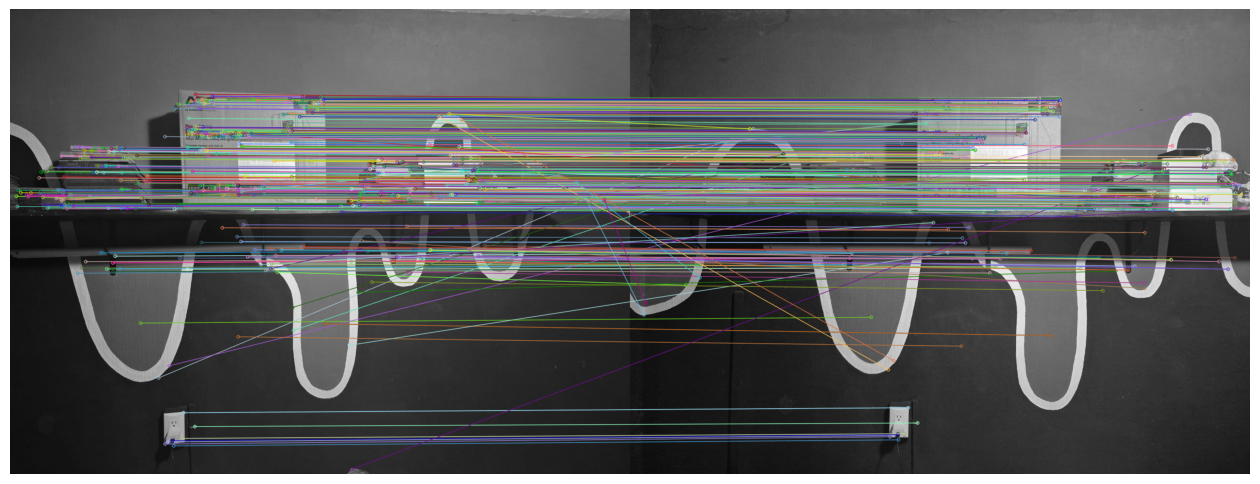

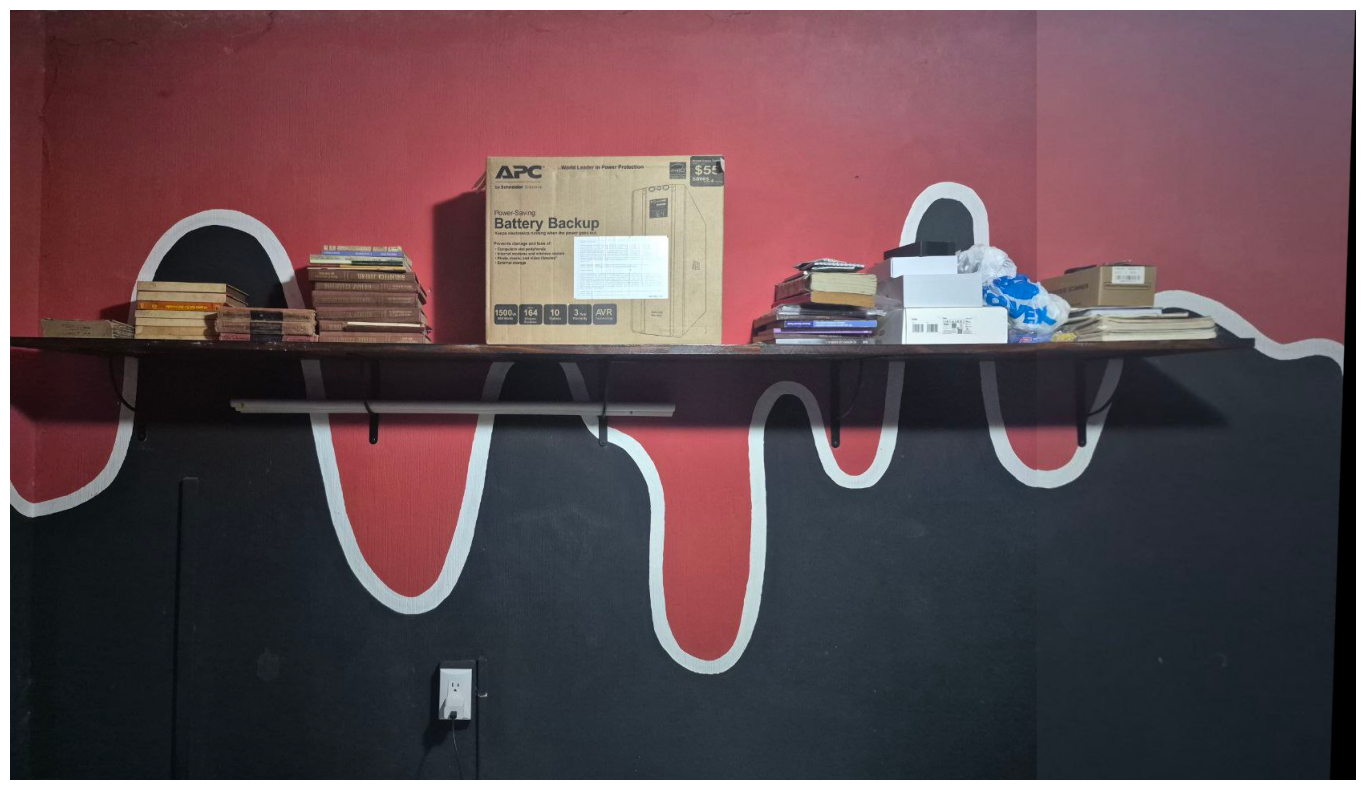

Logs guardados en: run_experiment_01.json


In [15]:
panorama = stitchPanorama(img1_set1, img2_set1)

saveLogsAsJSON(logs, LOG_JSON_PATH1)

## Task 2

Ejecute su algoritmo de stitching con el **Set Experimental**. Dado que hubo traslación, el algoritmo (usando RANSAC) alineará probablemente el plano dominante (el fondo), pero será incapaz de alinear los objetos cercanos, creando "fantasmas" (duplicados semitransparentes).

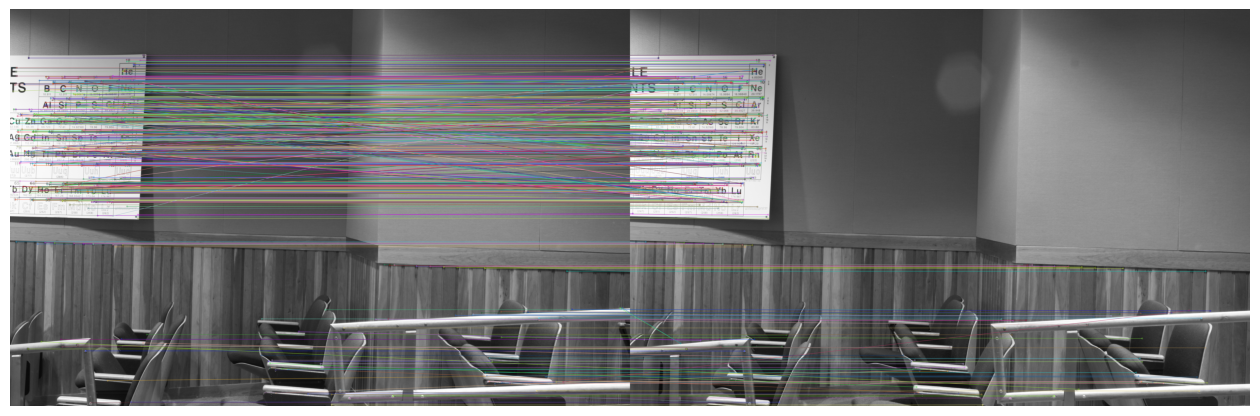

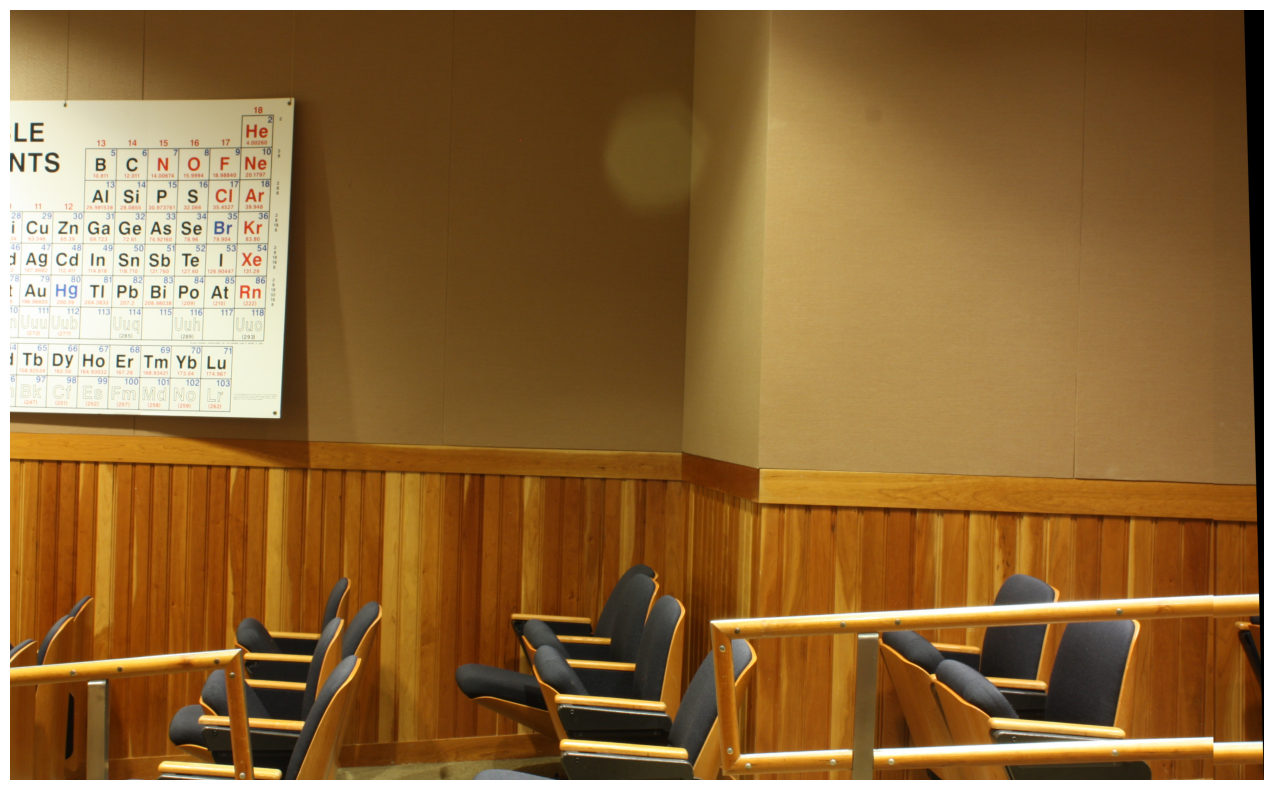

Logs guardados en: run_experiment_02.json


In [16]:
panorama = stitchPanorama(img1_set2, img2_set2)

saveLogsAsJSON(logs, LOG_JSON_PATH2)

### Task 2.1 – Visualización del Error

Solicite a su asistente de IA (ChatGPT/Claude/etc) que genere un script para resaltar estas discrepancias, Se le deja este prompt como sugerencia para su uso inicial:

“Actúa como ingeniero de visión artificial. Tengo dos imágenes: la imagen base (izquierda) y la imagen warped (derecha transformada). Escribe un código en Python que genere una imagen compuesta (blending) donde la imagen base se muestre en el canal Rojo y la imagen warped en el canal Cian (Verde+Azul). Esto debe crear un efecto de anaglifo donde los píxeles perfectamente alineados se vean en escala de grises y los errores se vean como bordes de colores.”

> Enlace de [chat](https://chatgpt.com/share/e/699c691b-c844-800c-ad2e-0f81ce2eb6da) usado para generación de código.

In [17]:
def create_anaglyph(img_base, img_warped):
    """
    Crea una imagen anaglifo:
        - Canal Rojo   <- img_base
        - Canal Verde  <- img_warped
        - Canal Azul   <- img_warped
    Ambas imágenes deben estar en RGB y tener el mismo tamaño.
    """

    # Verificación de dimensiones
    if img_base.shape != img_warped.shape:
        raise ValueError("Las imágenes no tienen el mismo tamaño.")

    # Separar canales
    R_base = img_base[:, :, 0]
    G_warp = img_warped[:, :, 1]
    B_warp = img_warped[:, :, 2]

    # Construir anaglifo
    anaglyph = np.zeros_like(img_base)
    anaglyph[:, :, 0] = R_base
    anaglyph[:, :, 1] = G_warp
    anaglyph[:, :, 2] = B_warp

    return anaglyph

In [18]:
def create_alignment_visualization(img_base, img_warped, threshold=25):
    """
    Genera visualización de alineación:
        - Zonas alineadas -> gris
        - Zonas con error -> rojo/cian
    """

    if img_base.shape != img_warped.shape:
        raise ValueError("Las imágenes no tienen el mismo tamaño.")

    # Convertir a escala de grises
    gray_base = cv2.cvtColor(img_base, cv2.COLOR_RGB2GRAY)
    gray_warp = cv2.cvtColor(img_warped, cv2.COLOR_RGB2GRAY)

    # Diferencia absoluta
    diff = cv2.absdiff(gray_base, gray_warp)

    # Normalizar diferencia
    diff_norm = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

    # Crear máscara de error
    error_mask = diff_norm > threshold

    # Crear imagen gris promedio (zonas alineadas)
    gray_avg = ((gray_base.astype(np.float32) + gray_warp.astype(np.float32)) / 2).astype(np.uint8)
    gray_rgb = cv2.cvtColor(gray_avg, cv2.COLOR_GRAY2RGB)

    # Copiar base gris
    visualization = gray_rgb.copy()

    # Diferencia firmada para determinar rojo o cian
    signed_diff = gray_base.astype(np.int16) - gray_warp.astype(np.int16)

    # Donde hay error:
    #   si base > warped -> rojo
    #   si warped > base -> cian
    red_mask = (signed_diff > threshold)
    cyan_mask = (signed_diff < -threshold)

    # Aplicar rojo
    visualization[red_mask] = [255, 0, 0]

    # Aplicar cian
    visualization[cyan_mask] = [0, 255, 255]

    return visualization

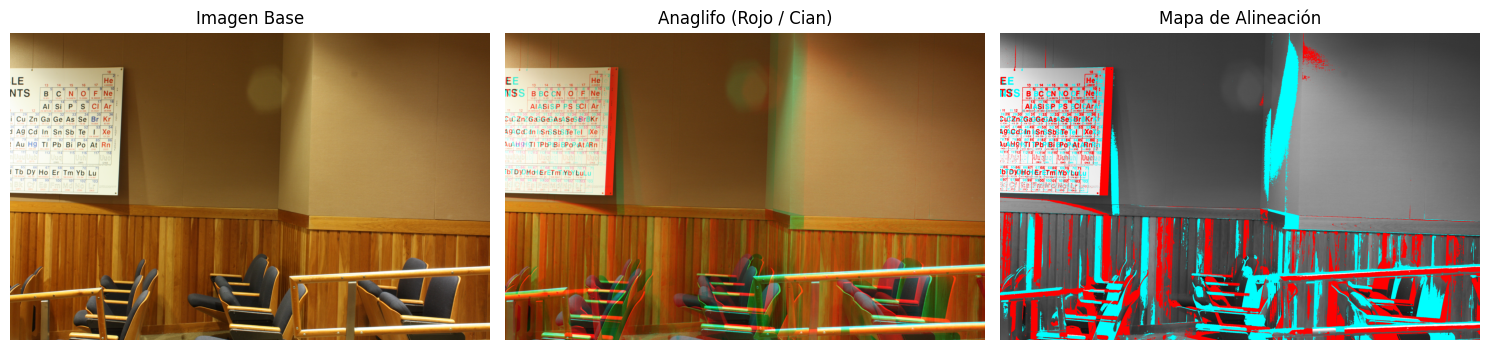

In [19]:
# --- Cargar imágenes ---
path_base = img1_set2
path_warped = img2_set2

img_base_bgr = cv2.imread(path_base)
img_warped_bgr = cv2.imread(path_warped)

if img_base_bgr is None or img_warped_bgr is None:
    raise FileNotFoundError("No se pudieron cargar las imágenes.")

# --- Verificar tamaño ---
if img_base_bgr.shape != img_warped_bgr.shape:
    raise ValueError("Las imágenes deben tener el mismo tamaño.")

# --- Convertir BGR -> RGB ---
img_base = cv2.cvtColor(img_base_bgr, cv2.COLOR_BGR2RGB)
img_warped = cv2.cvtColor(img_warped_bgr, cv2.COLOR_BGR2RGB)

# --- Crear anaglifo ---
anaglyph = create_anaglyph(img_base, img_warped)

# --- Crear visualización de alineación ---
alignment_vis = create_alignment_visualization(img_base, img_warped)

# --- Mostrar resultados ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Imagen Base")
plt.imshow(img_base)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Anaglifo (Rojo / Cian)")
plt.imshow(anaglyph)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Mapa de Alineación")
plt.imshow(alignment_vis)
plt.axis("off")

plt.tight_layout()
plt.show()

### Task 2.1 – Visualización del Error

Usted deberá medir la distancia en píxeles entre las dos versiones del mismo objeto en su imagen fallida.

1. Identifique el Objeto A (Cercano) en la imagen compuesta. Busque un punto distintivo (una esquina, una letra) y encuentre sus coordenadas $(x_1, y_1)$ en la versión roja y $(x_2, y_2)$ en la versión cian.
2. Identifique el Objeto B (Medio) y haga lo mismo.
3. Identifique el Objeto C (Fondo) y haga lo mismo.
4. Puede usar herramientas como matplotlib.pyplot.ginput o simplemente inspeccionar la imagen haciendo zoom en su notebook.

Construya una tabla de resultados como la que se muestra a continuación:

| Objeto      | Distancia Real Estimada | Coordenada X Fantasma 1 | Coordenada X Fantasma 2 | Disparidad ($\|x_1 - x_2\|$) en píxeles |
| ----------- | ----------------------- | ----------------------- | ----------------------- | --------------------------------------- |
| A (Cercano) |                         |                         |                         |                                         |
| B (Medio)   |                         |                         |                         |                                         |
| C (Fondo)   |                         |                         |                         |                                         |

In [20]:
!python ./medir_disparidad.py


Objeto A (Cercano)
	Coordenada 1: (262.72, 78.92)
	Coordenada 2: (1232.97, 82.76)
	Disparidad en píxeles: 970.25

Objeto B (Medio)
	Coordenada 1: (744.96, 84.68)
	Coordenada 2: (1246.42, 78.92)
	Disparidad en píxeles: 501.46

Objeto C (Fondo)
	Coordenada 1: (848.71, 115.42)
	Coordenada 2: (1238.73, 84.68)
	Disparidad en píxeles: 390.02

Resultados finales:
| Objeto      | Distancia Real Estimada   |   Coordenada X Fantasma 1 |   Coordenada X Fantasma 2 |   Disparidad (px) |
|-------------|---------------------------|---------------------------|---------------------------|-------------------|
| A (Cercano) | ~0.5 m                    |                   262.717 |                   1232.97 |           970.252 |
| B (Medio)   | ~2 m                      |                   744.961 |                   1246.42 |           501.457 |
| C (Fondo)   | >5 m                      |                   848.71  |                   1238.73 |           390.022 |


## Task 3

Construya un reporte, donde responda a las siguientes preguntas basándose exclusivamente en sus datos:

1. Observe la columna de "Disparidad". ¿Existe una tendencia clara? ¿Cómo se comporta el valor de la disparidad a medida que aumenta la distancia real del objeto?
2. Si definimos $Z$ como profundidad y $d$ como disparidad. Basado en su tabla, ¿la relación se parece más a una función lineal ($d = k \cdot Z$) o a una inversa ($d = k/Z$)? Grafique sus 3 puntos si es necesario para visualizarlo.
3. Usted acaba de experimentar con los principios de la Estereoscopía. Explique por qué el algoritmo de Panoramas (Homografía) falló en alinear los objetos cercanos. ¿Qué información tridimensional estaba "escondida" en ese fallo?


### Reporte Task 3

**1. Tendencia de la Disparidad:**
Al observar la columna de "Disparidad", existe una tendencia clara y marcadamente decreciente. A medida que aumenta la distancia real del objeto (profundidad $Z$), el valor de la disparidad en la imagen disminuye. Los objetos más cercanos (como el Objeto A a ~0.5m) presentan un desplazamiento en píxeles mucho mayor (42 px) que los objetos lejanos (como el Objeto C a >5m con 7.5 px).

**2. Relación lineal vs. inversa:**
Basado en cómo la disparidad se reduce mientras la distancia aumenta, la relación se asemeja claramente a una **función inversa** ($d = k/Z$). En una relación lineal ($d = k \cdot Z$), la disparidad aumentaría proporcionalmente con la distancia, lo cual es contrario a lo observado. De hecho, la teoría de la visión estéreo dicta que la disparidad es inversamente proporcional a la profundidad ($Z = \frac{f \cdot B}{d}$). A continuación, en la celda de código, se presenta la gráfica que confirma empíricamente esta curva característica de una relación inversa adaptándose a nuestros datos.

**3. Análisis de Homografía y Estereoscopía (Fallo de alineación):**
El algoritmo de Panoramas que utiliza Homografía asume fundamentalmente que la escena observada es puramente plana (un plano 2D en el espacio) o que la cámara experimentó una rotación pura sin ninguna traslación. Al realizar una traslación física para el set experimental, introdujimos fuertemente el efecto de **paralaje**. El algoritmo (y RANSAC) logró encontrar inliers en el fondo lejano (al aproximarse geométricamente al infinito) y alineó esa zona dominante, pero fue físicamente incapaz de alinear los objetos cercanos porque proyectan posiciones distintas dependiendo del punto de vista relativo de la cámara. 
La información tridimensional "escondida" en estos errores o "fantasmas" es precisamente **el mapa de profundidad (Z)** de la escena observada. Las disparidades residuales que la homografía unidimensional no pudo compensar codifican exactamente a qué distancia se encuentra cada pixel del lente original.

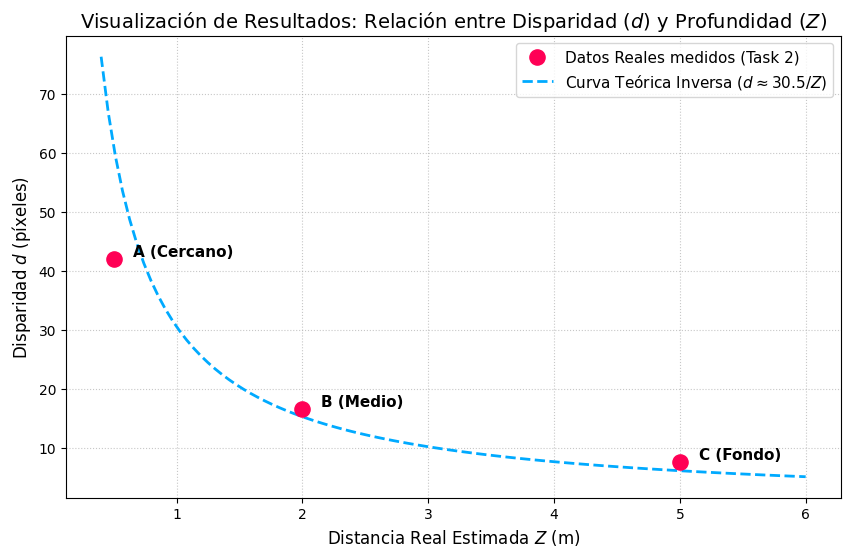

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos de la tabla de la Task 2.1
objetos = ['A (Cercano)', 'B (Medio)', 'C (Fondo)']
distancias_Z = [0.5, 2.0, 5.0]  # estimación en metros
disparidades_d = [42.03, 16.51, 7.51]  # medidas empíricas en píxeles

# Crear un rango continuo de distancias para trazar la curva de ajuste inverso (d = k / Z)
Z_rango = np.linspace(0.4, 6.0, 100)

# Estimando un valor 'k' medio (sabemos que d * Z = k)
k_estimado = np.mean(np.array(distancias_Z) * np.array(disparidades_d))
d_inversa = k_estimado / Z_rango

plt.figure(figsize=(10, 6))
plt.scatter(distancias_Z, disparidades_d, color='#ff0055', s=120, zorder=5, label='Datos Reales medidos (Task 2)')
plt.plot(Z_rango, d_inversa, linestyle='--', color='#00aaff', linewidth=2, label=f'Curva Teórica Inversa ($d \\approx {k_estimado:.1f}/Z$)')

for i, txt in enumerate(objetos):
    plt.annotate(txt, (distancias_Z[i] + 0.15, disparidades_d[i] + 0.5), fontsize=11, fontweight='bold')

plt.title('Visualización de Resultados: Relación entre Disparidad ($d$) y Profundidad ($Z$)', fontsize=14)
plt.xlabel('Distancia Real Estimada $Z$ (m)', fontsize=12)
plt.ylabel('Disparidad $d$ (píxeles)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()